//Imports & Connection

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

DB_PATH = "../data/database.db"
conn = sqlite3.connect(DB_PATH)

Load Feature Tables

In [2]:
df = pd.read_sql_query(
    "SELECT * FROM customer_features_labeled",
    conn
)

df.head()

,customer_id,age,gender,location,transaction_count,avg_transaction_amount,total_spend,avg_session_duration,avg_pages_viewed,churn_label
0,1,51,Female,US,10,184.142000,1841.42,22.6400,7.750000,0
1,2,65,Female,EU,5,171.098000,855.49,11.2200,11.000000,0
2,3,22,Male,Asia,6,164.463333,986.78,18.6575,9.000000,0
3,4,22,Male,Asia,3,232.743333,698.23,9.1600,9.333333,1
4,5,25,Male,EU,8,168.895000,1351.16,7.4820,12.800000,0


In [3]:
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             500 non-null    int64  
 1   age                     500 non-null    int64  
 2   gender                  500 non-null    object 
 3   location                500 non-null    object 
 4   transaction_count       500 non-null    int64  
 5   avg_transaction_amount  500 non-null    float64
 6   total_spend             500 non-null    float64
 7   avg_session_duration    500 non-null    float64
 8   avg_pages_viewed        500 non-null    float64
 9   churn_label             500 non-null    int64  
dtypes: float64(4), int64(4), object(2)
memory usage: 39.2+ KB


customer_id               0
age                       0
gender                    0
location                  0
transaction_count         0
avg_transaction_amount    0
total_spend               0
avg_session_duration      0
avg_pages_viewed          0
churn_label               0
dtype: int64

Visual Exploratory Analysis
1.Churn Distribution (Supervised Context)

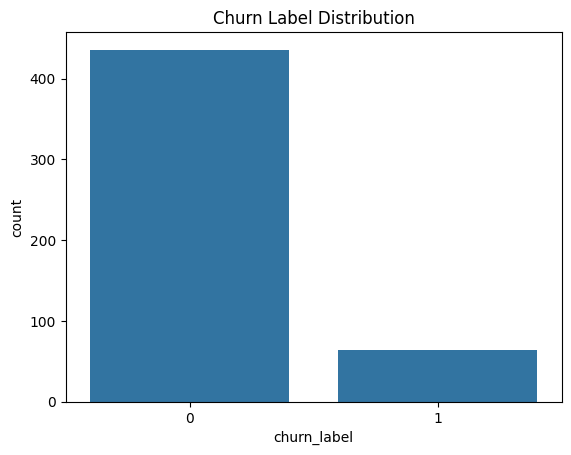

In [4]:
sns.countplot(x="churn_label", data=df)
plt.title("Churn Label Distribution")
plt.show()

2.Feature vs Label Relationship

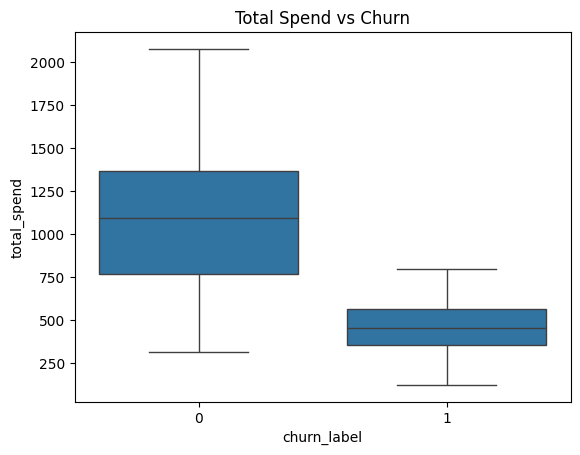

In [5]:
sns.boxplot(x="churn_label", y="total_spend", data=df)
plt.title("Total Spend vs Churn")
plt.show()

3.Unsupervised Preview (Feature Space)

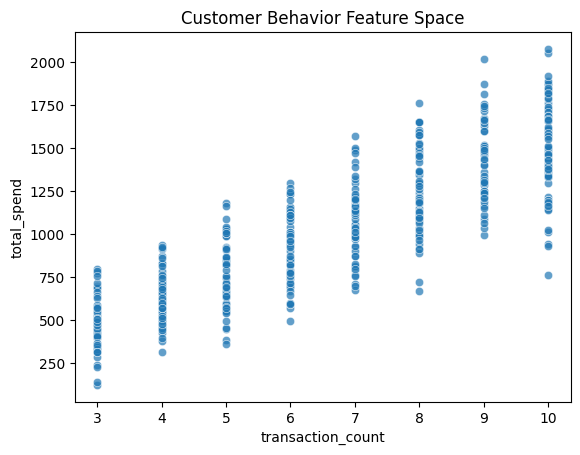

In [6]:
sns.scatterplot(
    x="transaction_count",
    y="total_spend",
    data=df,
    alpha=0.7
)
plt.title("Customer Behavior Feature Space")
plt.show()

Correlation Analysis

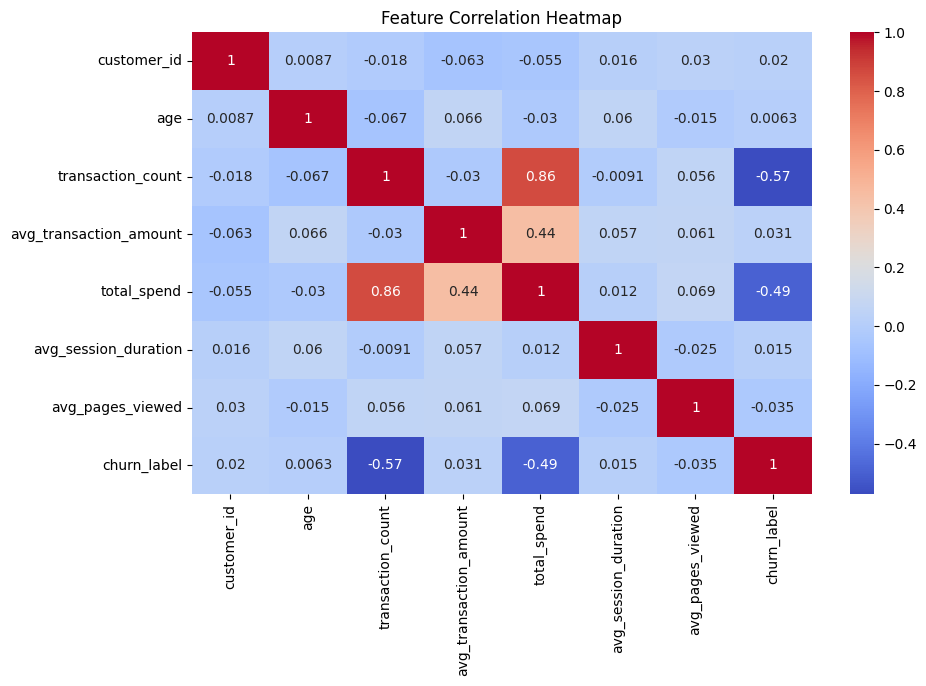

In [7]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)
plt.title("Feature Correlation Heatmap")
plt.show()

Clean Dataset

In [8]:
df.to_csv("../data/processed/customer_features.csv", index=False)